INFO:bbtransformer.trainer.exe:Loading data for target='target_label'
INFO:bbtransformer.trainer.exe:fMRI shape: (374, 150, 414), Subjects: 374
INFO:bbtransformer.trainer.exe:Dataset metadata: {'target': 'target_label', 'n_total': 374, 'n_positive': 271, 'prevalence': 0.7245989441871643, 'feature_dim': 414, 'n_train': 261, 'n_val': 56, 'n_test': 57}


Cohort: 374 subjects (271 cases, 103 controls, 72.5% prevalence)
Splits → Train: 261, Val: 56, Test: 57


INFO:bbtransformer.trainer.exe:Model created on cuda with 29354880 parameters
INFO:bbtransformer.trainer.exe:Pretrained weights loaded from /mnt/movement/users/jaizor/xtra/notebooks/BBT/analysis/weights/neuroX.pth


Attempting SAFE load (on CPU first): /mnt/movement/users/jaizor/xtra/notebooks/BBT/analysis/weights/neuroX.pth
✓ Successfully loaded 100 layers from: /mnt/movement/users/jaizor/xtra/notebooks/BBT/analysis/weights/neuroX.pth


✓ Saved SAFE weights (weights_only=True compatible) to: weights/weights_target_label.pth


INFO:bbtransformer.trainer.exe:Performance Metrics:      
INFO:bbtransformer.trainer.exe:  Accuracy:  0.9825
INFO:bbtransformer.trainer.exe:  Precision: 1.0000
INFO:bbtransformer.trainer.exe:  Recall:    0.9756
INFO:bbtransformer.trainer.exe:  F1 Score:  0.9877
INFO:bbtransformer.trainer.exe:  ROC-AUC:   1.0000
INFO:bbtransformer.trainer.exe:Computing permutation importance (metric=loss, repeats=5)


Calculating permutation importance (loss) for 414 brain regions...


Permuting regions: 100%|██████████| 414/414 [04:30<00:00,  1.53it/s]
INFO:bbtransformer.trainer.exe:Permutation importance computation complete.


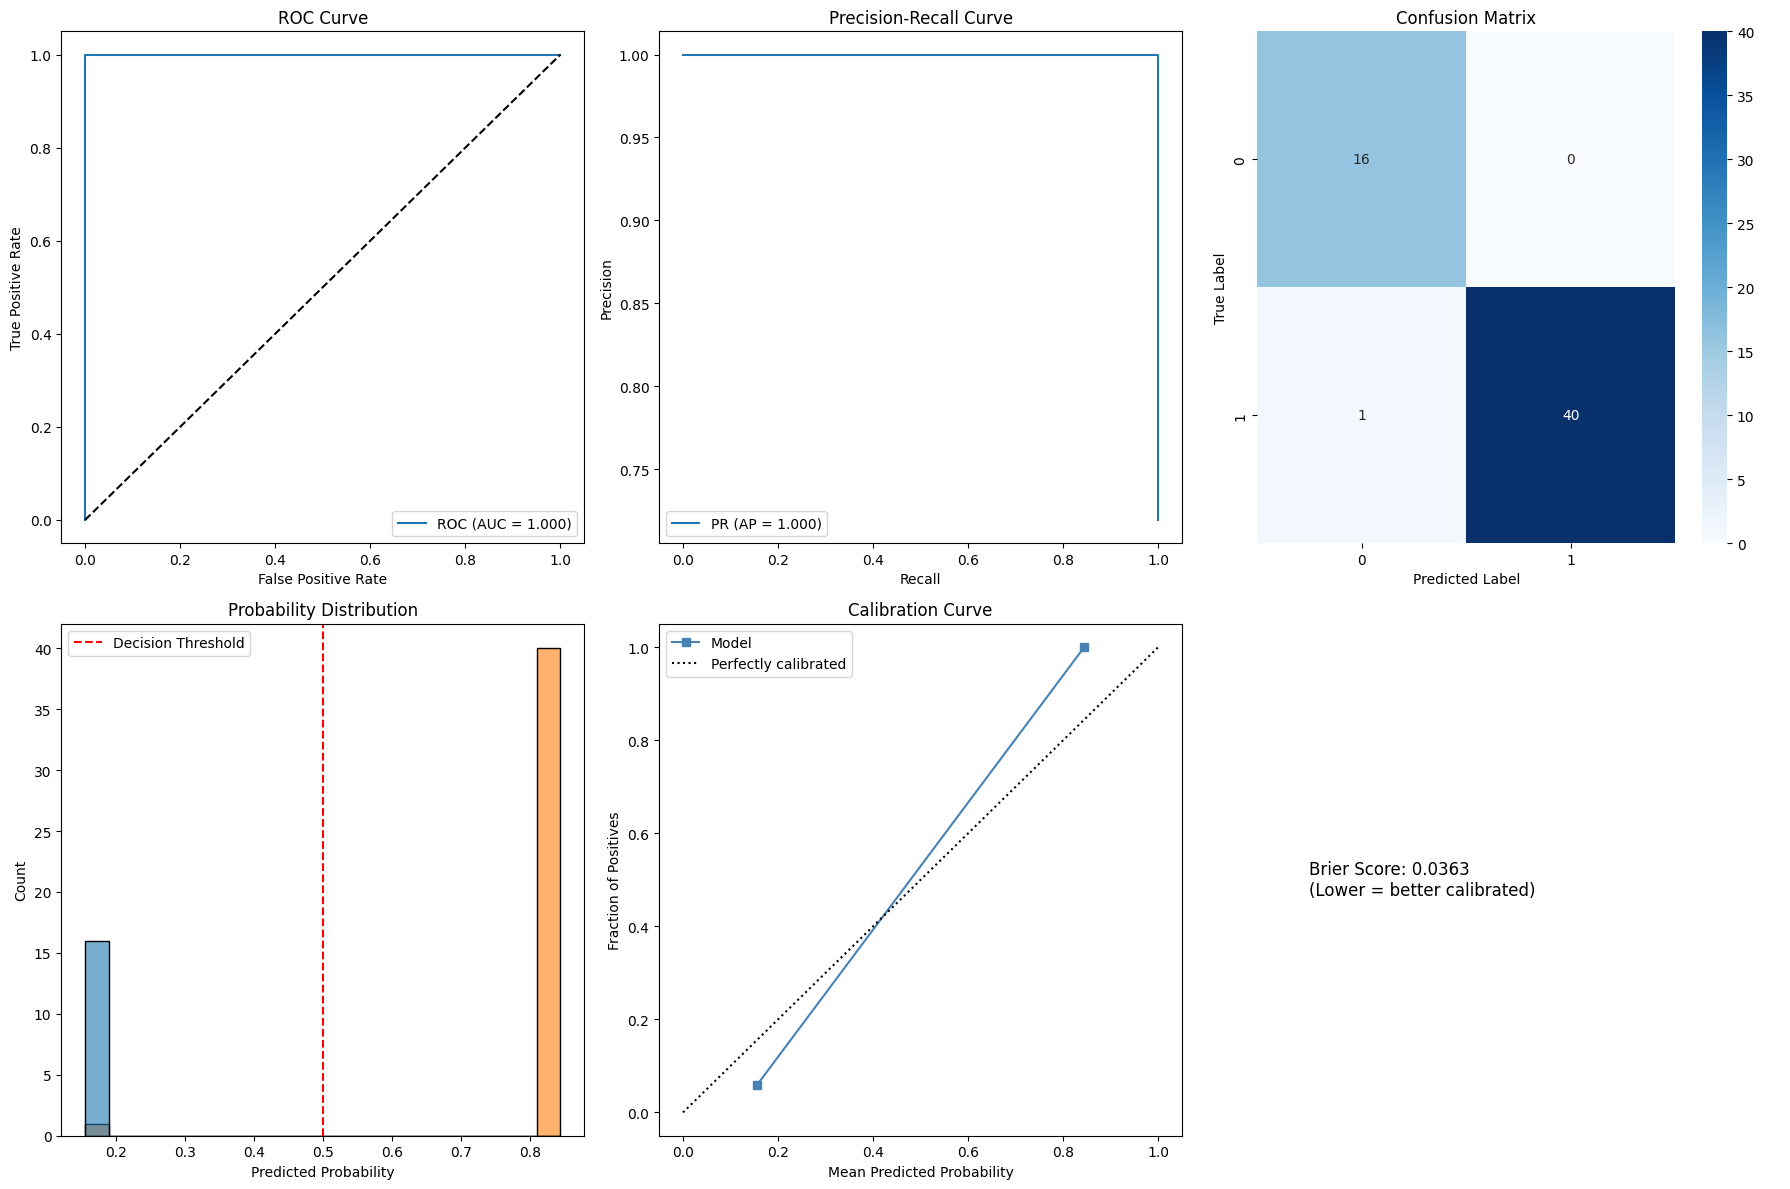

✅ Saved evaluation plots to results/target_label_results.png
Saved top 5 features to: results/importance_target_label.csv


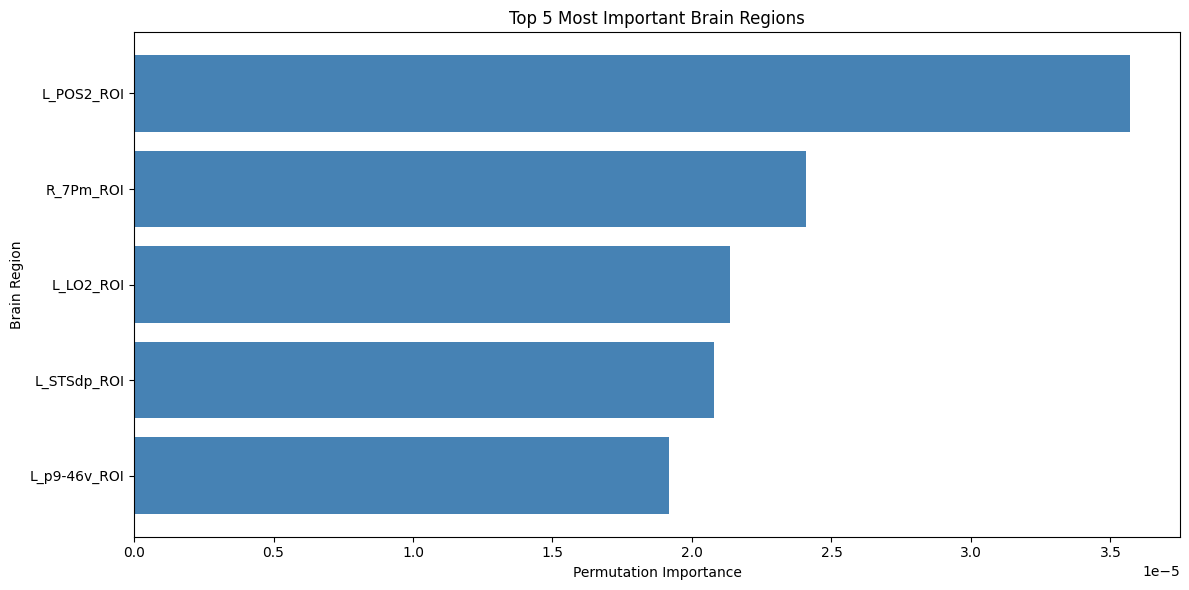

INFO:bbtransformer.trainer.exe:Results saved to JSON: results/target_label_results.json
INFO:bbtransformer.trainer.exe:Training & evaluation complete for target: target_label


Saved plot to results/importance_target_label_plot.png


In [ ]:
# Fine-tune BBTransformer ASD vs ADHD
import logging
from pathlib import Path

from bbtransformer.trainer.exe import run_analysis

logging.basicConfig(level=logging.INFO)

BASE_DIR = Path("/data/fmri/chrt")
DATA_PATH = BASE_DIR / "fmri_ASD_vs_ADHD.npz"       
PHENO_PATH = BASE_DIR / "pheno_ASD_vs_ADHD.csv"     
PRE_WEIGHTS = "neuroX.pth"                           

results = run_analysis(
    # --- DATA IDENTIFICATION ---
    target_column="target_label",
    data_path=str(DATA_PATH),
    pheno_path=str(PHENO_PATH),
    base_dir=None,

    # --- PROJECT STRUCTURE ---
    project_root=".",
    use_pretrained=True,
    pretrained_weight_file= PRE_WEIGHTS,

    # --- TRAINING HYPERPARAMETERS ---
    training_config={
        "epochs": 500,
        "lr": 1e-5,
        "weight_decay": 1.14e-06,
        "patience": 50,
    },
    early_stop_metric="loss",
    use_focal_loss=False,

    # --- MODEL ARCHITECTURE ---
    model_config=None,

    # --- IMPORTANCE ANALYSIS ---
    compute_importance=True,
    importance_metric="loss",
    importance_n_repeats=5,

    # --- REPRODUCIBILITY AND HARDWARE ---
    random_seed=42,
    device=None,

    # --- OUTPUT CONTROL ---
    save_plots=True,
    save_json=True,
)